# Copenhagen Networks Study — Exploratory Data Analysis

**Context.** This dataset records four weeks of interactions among ~850 university students at DTU: Bluetooth proximity pings, phone calls, SMS, Facebook friendships, and self-reported gender. The end goal for this project is to model how information (or a rumor) could spread through this population, so this notebook focuses on what matters for that: network topology (who *can* reach whom), temporal rhythm (when contacts happen), and tie strength (how strong each channel of contact is).

**Source.** Raw files live in `data/raw/` — see `Instruction.md` for provenance and the Figshare DOI. Nothing in `data/raw/` is modified here; all work happens in memory within this notebook.

**Sections**
1. Dataset overview
2. Temporal dynamics — activity over the 4 weeks
3. Network structure — degree distributions & a friendship-graph visualization
4. Tie strength — call durations, missed calls, interaction frequency per pair
5. Proximity signal strength (Bluetooth RSSI)
6. Cross-layer overlap — how much do channels agree on who is "connected"?
7. Summary — implications for rumor-spread modeling

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import networkx as nx
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

DATA_DIR = Path("../data/raw")
SECONDS_PER_DAY = 86_400

BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED = (
    "#2a78d6", "#eb6834", "#1baf7a", "#eda100",
    "#e87ba4", "#008300", "#4a3aa7", "#e34948",
)
INK, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
SEQ_BLUE = LinearSegmentedColormap.from_list("seq_blue", ["#cde2fb", "#3987e5", "#0d366b"])

LAYER_COLOR = {
    "Calls": BLUE,
    "SMS": ORANGE,
    "Proximity (Bluetooth)": AQUA,
    "Facebook friends": VIOLET,
}
GENDER_COLOR = {"Male": BLUE, "Female": VIOLET}

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "axes.edgecolor": BASELINE,
    "axes.labelcolor": INK,
    "text.color": INK,
    "xtick.color": INK_SECONDARY,
    "ytick.color": INK_SECONDARY,
    "grid.color": GRID,
    "grid.linewidth": 0.7,
    "axes.grid": True,
    "axes.axisbelow": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "figure.dpi": 110,
})

## Load the raw data

Every file in `data/raw/` is read as-is. `bt_symmetric.csv`, `fb_friends.csv`, and `genders.csv` use a `#`-prefixed header line, so those are read with `comment="#"` and explicit column names; `calls.csv` and `sms.csv` have ordinary headers.

Bluetooth rows with `user_b == -1` (empty scan) or `-2` (a non-experiment device) are dropped for anything that needs a real second participant — they aren't a contact between two study members.

In [2]:
def read_hash_csv(path, names, dtype=None):
    return pd.read_csv(path, comment="#", names=names, dtype=dtype)


def pair_id(df, col_a, col_b):
    a = np.minimum(df[col_a], df[col_b]).astype(np.int64)
    b = np.maximum(df[col_a], df[col_b]).astype(np.int64)
    return a * 10_000 + b


calls = pd.read_csv(DATA_DIR / "calls.csv")
sms = pd.read_csv(DATA_DIR / "sms.csv")
bt = read_hash_csv(
    DATA_DIR / "bt_symmetric.csv",
    names=["timestamp", "user_a", "user_b", "rssi"],
    dtype={"timestamp": "int32", "user_a": "int32", "user_b": "int32", "rssi": "int16"},
)
fb = read_hash_csv(DATA_DIR / "fb_friends.csv", names=["user_a", "user_b"])
genders = read_hash_csv(DATA_DIR / "genders.csv", names=["user", "female"])

bt_valid = bt[bt.user_b >= 0].copy()

for df in (calls, sms, bt_valid):
    df["day"] = df["timestamp"] // SECONDS_PER_DAY

calls["pair"] = pair_id(calls, "caller", "callee")
sms["pair"] = pair_id(sms, "sender", "recipient")
bt_valid["pair"] = pair_id(bt_valid, "user_a", "user_b")

print(f"calls:            {len(calls):>10,} rows")
print(f"sms:              {len(sms):>10,} rows")
print(f"bluetooth scans:  {len(bt):>10,} rows  ({len(bt_valid):,} are valid in-experiment contacts)")
print(f"facebook edges:   {len(fb):>10,} rows")
print(f"gender labels:    {len(genders):>10,} participants")

calls:                 3,600 rows
sms:                  24,333 rows
bluetooth scans:   5,474,289 rows  (2,426,279 are valid in-experiment contacts)
facebook edges:        6,429 rows
gender labels:           787 participants


## 1. Dataset overview

Four interaction layers, each covering roughly the same 4-week window, plus a static Facebook friendship snapshot and gender labels for a subset of participants.

In [3]:
def unique_users(df, cols):
    users = pd.concat([df[c] for c in cols])
    return users[users >= 0].nunique()


overview = pd.DataFrame([
    {
        "layer": "Calls",
        "records": len(calls),
        "unique_users": unique_users(calls, ["caller", "callee"]),
        "span_days": round(calls["timestamp"].max() / SECONDS_PER_DAY, 1),
    },
    {
        "layer": "SMS",
        "records": len(sms),
        "unique_users": unique_users(sms, ["sender", "recipient"]),
        "span_days": round(sms["timestamp"].max() / SECONDS_PER_DAY, 1),
    },
    {
        "layer": "Proximity (Bluetooth)",
        "records": len(bt_valid),
        "unique_users": unique_users(bt_valid, ["user_a", "user_b"]),
        "span_days": round(bt["timestamp"].max() / SECONDS_PER_DAY, 1),
    },
    {
        "layer": "Facebook friends",
        "records": len(fb),
        "unique_users": unique_users(fb, ["user_a", "user_b"]),
        "span_days": np.nan,
    },
    {
        "layer": "Gender labels",
        "records": len(genders),
        "unique_users": genders["user"].nunique(),
        "span_days": np.nan,
    },
]).set_index("layer")

overview.style.format(
    {"records": "{:,}", "unique_users": "{:,}", "span_days": "{:.1f}"}, na_rep="static snapshot"
).set_caption("Table 1. One row per data layer in data/raw/")

,records,unique_users,span_days
layer,,,
Calls,"3,600",536,28.0
SMS,"24,333",568,28.0
Proximity (Bluetooth),"2,426,279",692,28.0
Facebook friends,"6,429",800,static snapshot
Gender labels,787,787,static snapshot


Roughly 780–850 people appear somewhere in the data, but only 787 have a declared gender label — any model that conditions on gender will need to handle the rest as "unknown" rather than drop them.

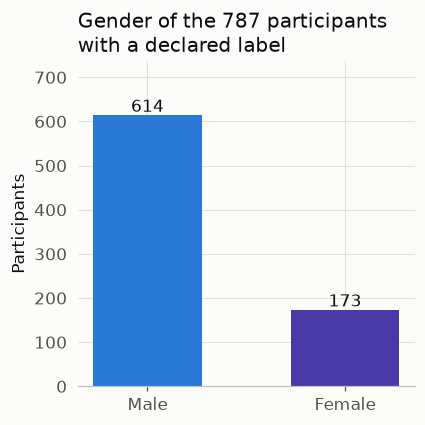

In [4]:
gender_counts = (
    genders["female"].map({0: "Male", 1: "Female"}).value_counts().reindex(["Male", "Female"])
)

fig, ax = plt.subplots(figsize=(4, 4))
bars = ax.bar(
    gender_counts.index, gender_counts.values,
    color=[GENDER_COLOR[g] for g in gender_counts.index], width=0.55,
)
for bar, value in zip(bars, gender_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 8, f"{value}", ha="center", color=INK)
ax.set_ylabel("Participants")
ax.set_title(f"Gender of the {len(genders)} participants\nwith a declared label", loc="left")
ax.spines["left"].set_visible(False)
ax.tick_params(left=False)
ax.set_ylim(0, gender_counts.max() * 1.2)
plt.tight_layout()
plt.show()

## 2. Temporal dynamics — activity over the 4 weeks

Rumor spread over a *temporal* network depends on when edges are "active," not just whether they exist at all — a static, time-collapsed graph would overstate how fast something could travel. We look at daily volume first, then the within-week rhythm.

Timestamps are seconds since the start of the study (day 0). The public release does not include an absolute calendar date, so weekday names aren't available — instead we use `study_day mod 7` to look for a roughly weekly cycle without asserting which day is "Monday."

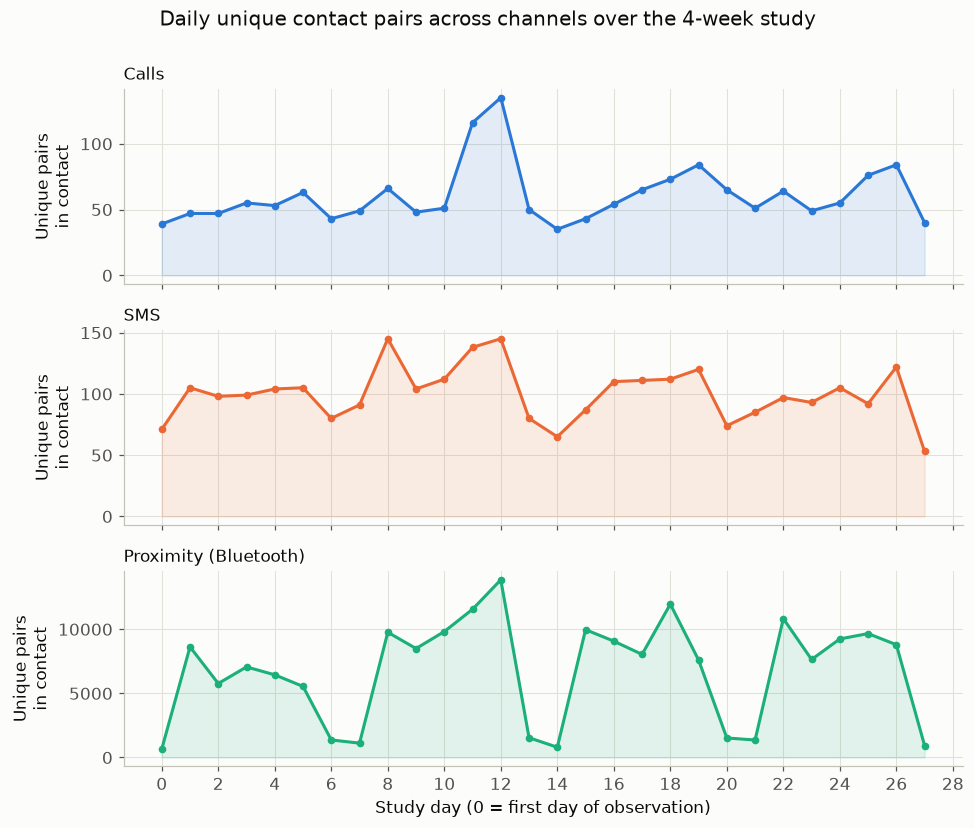

In [5]:
daily_series = [
    ("Calls", calls.groupby("day")["pair"].nunique(), LAYER_COLOR["Calls"]),
    ("SMS", sms.groupby("day")["pair"].nunique(), LAYER_COLOR["SMS"]),
    ("Proximity (Bluetooth)", bt_valid.groupby("day")["pair"].nunique(), LAYER_COLOR["Proximity (Bluetooth)"]),
]

fig, axes = plt.subplots(3, 1, figsize=(9, 7.5), sharex=True)
for ax, (label, s, color) in zip(axes, daily_series):
    ax.plot(s.index, s.values, color=color, linewidth=2, marker="o", markersize=4)
    ax.fill_between(s.index, s.values, color=color, alpha=0.12)
    ax.set_ylabel("Unique pairs\nin contact")
    ax.set_title(label, loc="left", fontsize=11)
axes[-1].set_xlabel("Study day (0 = first day of observation)")
axes[-1].set_xticks(range(0, 29, 2))
fig.suptitle("Daily unique contact pairs across channels over the 4-week study", y=1.0)
plt.tight_layout()
plt.show()

A clear ~7-day cycle is visible in all three channels, with recurring dips — almost certainly weekends. The next chart checks the hour-of-day pattern within that cycle.

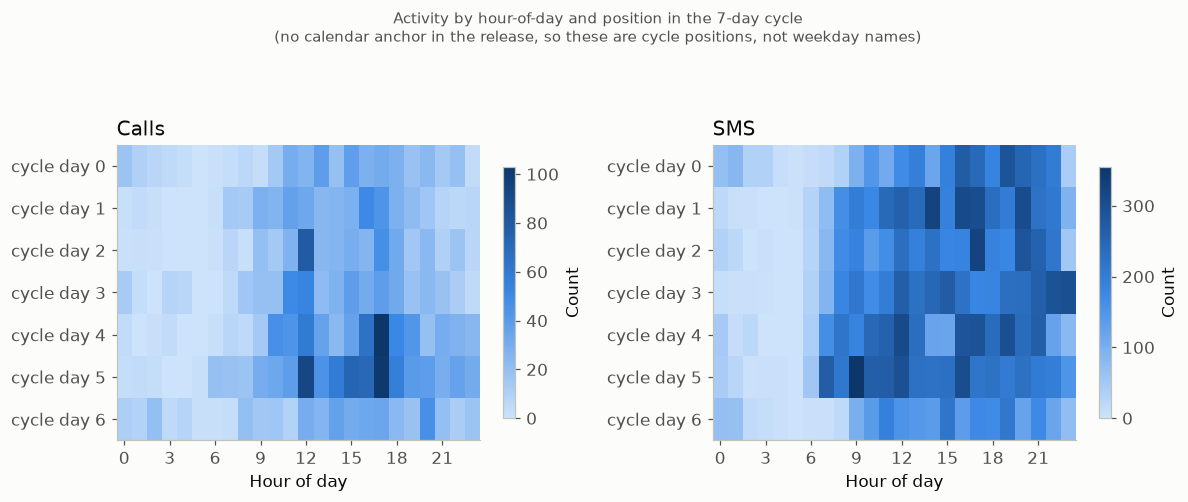

In [6]:
def hour_cycle_matrix(df, ts_col="timestamp"):
    hour = (df[ts_col] // 3600) % 24
    cycle_day = (df[ts_col] // SECONDS_PER_DAY) % 7
    mat = pd.crosstab(cycle_day, hour)
    return mat.reindex(index=range(7), columns=range(24), fill_value=0)


calls_mat = hour_cycle_matrix(calls)
sms_mat = hour_cycle_matrix(sms)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, mat, label in zip(axes, [calls_mat, sms_mat], ["Calls", "SMS"]):
    im = ax.imshow(mat.values, cmap=SEQ_BLUE, aspect="auto")
    ax.set_xticks(range(0, 24, 3))
    ax.set_xticklabels(range(0, 24, 3))
    ax.set_yticks(range(7))
    ax.set_yticklabels([f"cycle day {i}" for i in range(7)])
    ax.set_xlabel("Hour of day")
    ax.set_title(label, loc="left")
    ax.grid(False)
    cbar = fig.colorbar(im, ax=ax, shrink=0.85)
    cbar.set_label("Count")
fig.suptitle(
    "Activity by hour-of-day and position in the 7-day cycle\n"
    "(no calendar anchor in the release, so these are cycle positions, not weekday names)",
    y=1.08, fontsize=10, color=INK_SECONDARY,
)
plt.tight_layout()
plt.show()

## 3. Network structure — who can reach whom

For rumor spread, topology decides how far and how fast something can travel. We build one graph per layer and compare degree distributions, then visualize the Facebook friendship graph directly.

In [7]:
def build_graph(df, col_a, col_b, weighted=False):
    G = nx.Graph()
    if weighted:
        edges = df.groupby([col_a, col_b]).size().reset_index(name="weight")
        G.add_weighted_edges_from(edges.values)
    else:
        G.add_edges_from(df[[col_a, col_b]].values)
    return G


G_calls = build_graph(calls, "caller", "callee", weighted=True)
G_sms = build_graph(sms, "sender", "recipient", weighted=True)
G_bt = build_graph(bt_valid, "user_a", "user_b", weighted=True)
G_fb = build_graph(fb, "user_a", "user_b")

graphs = {
    "Calls": G_calls,
    "SMS": G_sms,
    "Proximity (Bluetooth)": G_bt,
    "Facebook friends": G_fb,
}
degree_data = {label: dict(G.degree()) for label, G in graphs.items()}

graph_summary = pd.DataFrame(
    {label: {"nodes": G.number_of_nodes(), "edges": G.number_of_edges(),
             "max_degree": max(dict(G.degree()).values())}
     for label, G in graphs.items()}
).T
graph_summary.style.format("{:,.0f}").set_caption("Table 2. Graph size per layer")

,nodes,edges,max_degree
Calls,536,621,18
SMS,568,697,11
Proximity (Bluetooth),692,"79,530",500
Facebook friends,800,"6,429",101


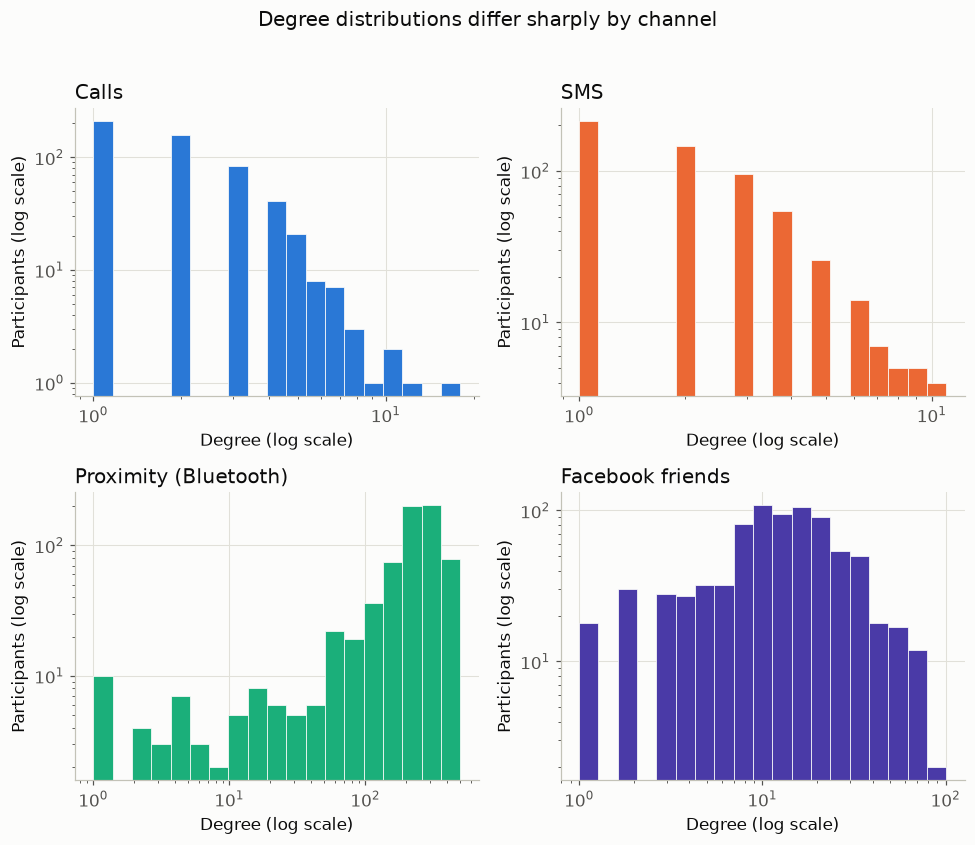

,mean,median,p90,max,skew
Calls,2.3,2.0,4.0,18.0,3.5
SMS,2.5,2.0,5.0,11.0,1.8
Proximity (Bluetooth),229.9,236.5,366.9,500.0,-0.3
Facebook friends,16.1,13.0,32.0,101.0,2.1


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(9, 7.5))
for ax, (label, degrees) in zip(axes.flat, degree_data.items()):
    values = np.array(list(degrees.values()))
    values = values[values > 0]
    bins = np.logspace(0, np.log10(values.max()), 20)
    ax.hist(values, bins=bins, color=LAYER_COLOR[label], edgecolor=SURFACE, linewidth=0.5)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(label, loc="left")
    ax.set_xlabel("Degree (log scale)")
    ax.set_ylabel("Participants (log scale)")
fig.suptitle("Degree distributions differ sharply by channel", y=1.02)
plt.tight_layout()
plt.show()

degree_stats = pd.DataFrame({
    label: {
        "mean": np.mean(list(d.values())),
        "median": np.median(list(d.values())),
        "p90": np.percentile(list(d.values()), 90),
        "max": np.max(list(d.values())),
        "skew": pd.Series(list(d.values())).skew(),
    }
    for label, d in degree_data.items()
}).T
degree_stats.style.format("{:.1f}").set_caption(
    "Table 3. Degree statistics per layer (skew > 0 = right-skewed / heavy-tailed)"
)

The four layers tell different stories. **Calls and SMS are sparse and heavy-tailed** (skew ≈ 3.5 and 1.8): the typical participant contacts only 2 people, but a few reach 10+, so those few act as bridges/hubs in an SIR-style model. **Facebook friendship is moderately heavy-tailed** (skew ≈ 2.1, median 13, max 101) — a normal social-network shape. **Bluetooth proximity is the opposite of heavy-tailed** (skew ≈ −0.3): a typical participant was recorded near roughly 230–240 other people over the 4 weeks, so almost everyone has broad physical reach. For rumor modeling, this means physical proximity is unlikely to be the bottleneck — nearly everyone *could* be reached that way — so the more interesting structure (who a rumor is *likely* to travel through, versus merely *could*) lives in the communication and friendship layers, not in raw proximity.

Next, the Facebook friendship graph itself — the one layer that's a static snapshot rather than a timestamped stream, so it's the most natural one to lay out as a whole-network picture.

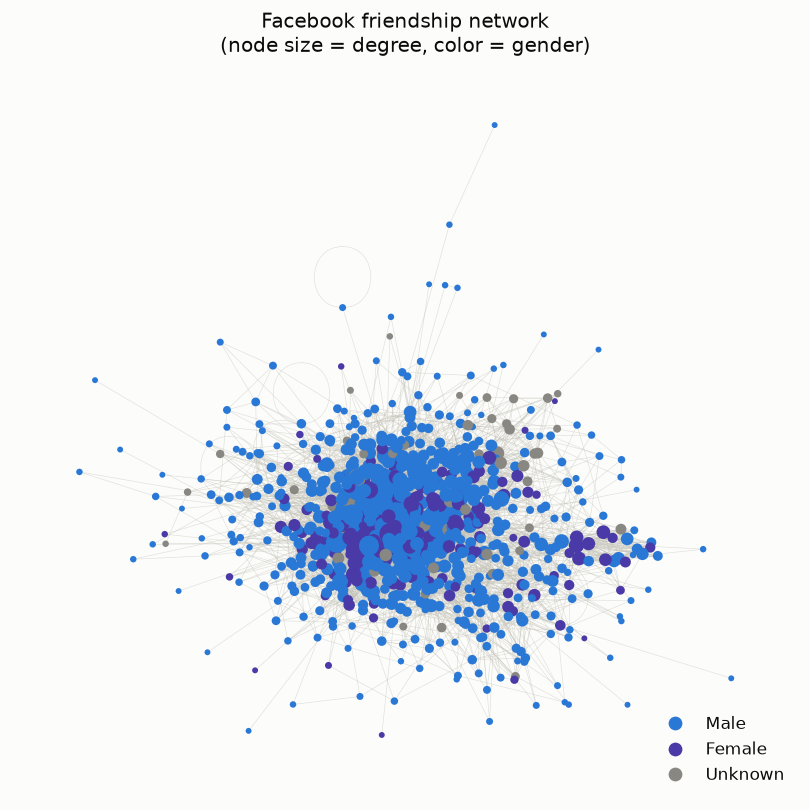

In [9]:
gender_map = genders.set_index("user")["female"].to_dict()

pos = nx.spring_layout(G_fb, seed=7, k=0.25)
node_colors = [
    GENDER_COLOR["Female"] if gender_map.get(n) == 1
    else GENDER_COLOR["Male"] if gender_map.get(n) == 0
    else INK_MUTED
    for n in G_fb.nodes()
]
node_sizes = [12 + 3 * G_fb.degree(n) for n in G_fb.nodes()]

fig, ax = plt.subplots(figsize=(7.5, 7.5))
nx.draw_networkx_edges(G_fb, pos, ax=ax, edge_color=BASELINE, width=0.4, alpha=0.5)
nx.draw_networkx_nodes(G_fb, pos, ax=ax, node_color=node_colors, node_size=node_sizes, linewidths=0)
ax.set_title("Facebook friendship network\n(node size = degree, color = gender)")
ax.axis("off")

handles = [
    plt.Line2D([0], [0], marker="o", linestyle="", color=c, label=l, markersize=8)
    for l, c in [("Male", GENDER_COLOR["Male"]), ("Female", GENDER_COLOR["Female"]), ("Unknown", INK_MUTED)]
]
ax.legend(handles=handles, loc="lower right", frameon=False)
plt.tight_layout()
plt.show()

### Face-to-face contact network (Bluetooth proximity)

The full proximity graph has 692 nodes and 79,530 edges — almost every pair who were *ever* scanned near each other, since a single 5-minute Bluetooth ping is enough to create an edge. Drawn as-is, that's an unreadable solid mass, and Section 3's degree analysis already showed it isn't hub-structured the way the other layers are.

To see meaningful face-to-face *social* structure — people who spent real, repeated time near each other rather than brushing past once in a hallway — we threshold to pairs with at least 30 cumulative hours of proximity across the 4 weeks (scans happen every 5 minutes, so that's ≥360 co-occurring scans).

Full proximity graph:         692 nodes,  79,530 edges
≥30h together (thresholded):  460 nodes,   1,004 edges


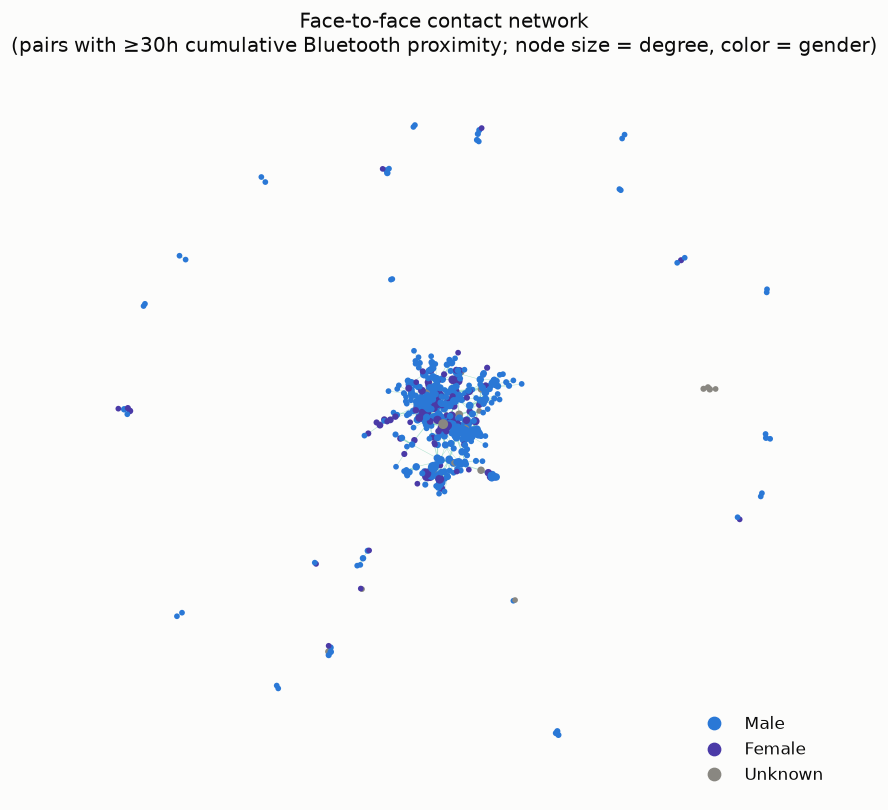

In [10]:
SCAN_INTERVAL_MIN = 5
MIN_HOURS_TOGETHER = 30
scan_threshold = int(MIN_HOURS_TOGETHER * 60 / SCAN_INTERVAL_MIN)

bt_weight = bt_valid.groupby(["user_a", "user_b"]).size().reset_index(name="weight")
bt_strong = bt_weight[bt_weight.weight >= scan_threshold]

G_bt_strong = nx.Graph()
G_bt_strong.add_weighted_edges_from(bt_strong[["user_a", "user_b", "weight"]].values)

print(f"Full proximity graph:        {G_bt.number_of_nodes():>4} nodes, {G_bt.number_of_edges():>7,} edges")
print(f"≥{MIN_HOURS_TOGETHER}h together (thresholded): {G_bt_strong.number_of_nodes():>4} nodes, {G_bt_strong.number_of_edges():>7,} edges")

pos_bt = nx.spring_layout(G_bt_strong, seed=7, k=0.2, weight="weight")
node_colors_bt = [
    GENDER_COLOR["Female"] if gender_map.get(n) == 1
    else GENDER_COLOR["Male"] if gender_map.get(n) == 0
    else INK_MUTED
    for n in G_bt_strong.nodes()
]
node_sizes_bt = [12 + 2 * G_bt_strong.degree(n) for n in G_bt_strong.nodes()]
edge_weights = np.array([w for _, _, w in G_bt_strong.edges(data="weight")])
edge_widths = 0.3 + 2.5 * (edge_weights - edge_weights.min()) / (edge_weights.max() - edge_weights.min())

fig, ax = plt.subplots(figsize=(7.5, 7.5))
nx.draw_networkx_edges(
    G_bt_strong, pos_bt, ax=ax, edge_color=LAYER_COLOR["Proximity (Bluetooth)"],
    width=edge_widths, alpha=0.35,
)
nx.draw_networkx_nodes(
    G_bt_strong, pos_bt, ax=ax, node_color=node_colors_bt, node_size=node_sizes_bt, linewidths=0,
)
ax.set_title(
    f"Face-to-face contact network\n"
    f"(pairs with ≥{MIN_HOURS_TOGETHER}h cumulative Bluetooth proximity; node size = degree, color = gender)"
)
ax.axis("off")

handles = [
    plt.Line2D([0], [0], marker="o", linestyle="", color=c, label=l, markersize=8)
    for l, c in [("Male", GENDER_COLOR["Male"]), ("Female", GENDER_COLOR["Female"]), ("Unknown", INK_MUTED)]
]
ax.legend(handles=handles, loc="lower right", frameon=False)
plt.tight_layout()
plt.show()

Even after keeping only "real" repeated contact, 393 of the 460 people (85%) fall into one giant connected component — the other 67 people are scattered across 24 small clusters (mostly pairs, plus a few groups of 3–5) who spent real time with each other but not with the rest of the group. That giant component is the practical ceiling on rumor reach through face-to-face contact alone: a rumor introduced anywhere inside it could, in principle, travel to almost everyone in it through a chain of strong ties — but it can't reach the people in the small side clusters without some other channel (a call, an SMS, or a weaker/one-off proximity contact) bridging the gap.

### Critical connectors — who would fragment the network if removed?

A **cut vertex** (articulation point) is someone whose removal splits a connected group into two or more disconnected pieces — no one else provides an alternate path around them. We look for these inside the 393-person giant component identified above (the 24 small offshoot clusters are already disconnected, so removing anyone from them doesn't "split" anything further).

Giant component: 393 people
Cut vertices found: 80 (20% of the giant component)
  - cut off exactly 1 person: 45
  - cut off more than 1 person: 35
  - largest single removal separates: 8 people (2.0% of the giant component)


,degree,gender,people_cut_off
user,,,
262,11,Female,8
267,5,Male,8
269,4,Male,8
452,6,Unknown,7
528,3,Female,7
544,2,Male,6
433,6,Male,5
339,7,Male,4
687,4,Male,4


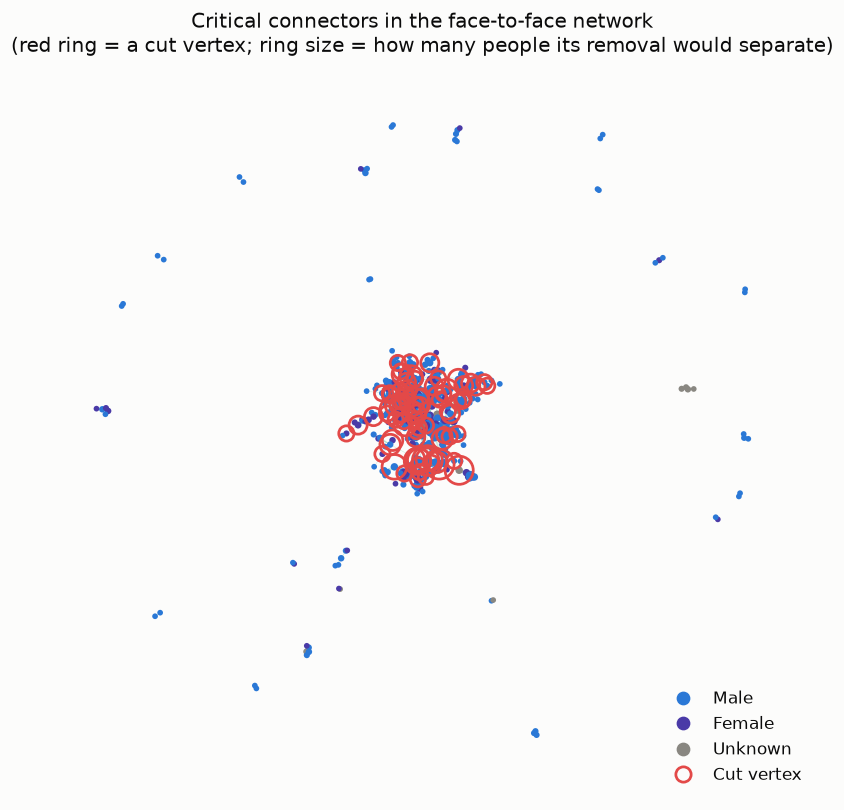

In [11]:
giant_nodes = max(nx.connected_components(G_bt_strong), key=len)
G_giant = G_bt_strong.subgraph(giant_nodes).copy()

articulation_points = list(nx.articulation_points(G_giant))

impact_rows = []
for ap in articulation_points:
    H = G_giant.copy()
    H.remove_node(ap)
    piece_sizes = sorted((len(c) for c in nx.connected_components(H)), reverse=True)
    impact_rows.append({
        "user": ap,
        "degree": G_giant.degree(ap),
        "gender": {0: "Male", 1: "Female"}.get(gender_map.get(ap), "Unknown"),
        "people_cut_off": sum(piece_sizes[1:]),
    })
impact = pd.DataFrame(impact_rows).sort_values("people_cut_off", ascending=False).reset_index(drop=True)

print(f"Giant component: {G_giant.number_of_nodes()} people")
print(f"Cut vertices found: {len(impact)} ({len(impact) / G_giant.number_of_nodes():.0%} of the giant component)")
print(f"  - cut off exactly 1 person: {(impact.people_cut_off == 1).sum()}")
print(f"  - cut off more than 1 person: {(impact.people_cut_off > 1).sum()}")
print(f"  - largest single removal separates: {impact.people_cut_off.max()} people "
      f"({impact.people_cut_off.max() / G_giant.number_of_nodes():.1%} of the giant component)")

display(
    impact.head(10).set_index("user").style.format({"degree": "{:.0f}", "people_cut_off": "{:.0f}"})
    .set_caption("Table 5. Top 10 cut vertices in the face-to-face network, ranked by how many people they'd separate from the main group")
)

ap_impact = impact.set_index("user")["people_cut_off"]
ap_sizes = [60 + 40 * ap_impact.loc[n] for n in articulation_points]

fig, ax = plt.subplots(figsize=(7.5, 7.5))
nx.draw_networkx_edges(
    G_bt_strong, pos_bt, ax=ax, edge_color=LAYER_COLOR["Proximity (Bluetooth)"], width=edge_widths, alpha=0.25,
)
nx.draw_networkx_nodes(G_bt_strong, pos_bt, ax=ax, node_color=node_colors_bt, node_size=node_sizes_bt, linewidths=0)
nx.draw_networkx_nodes(
    G_bt_strong, pos_bt, ax=ax, nodelist=articulation_points, node_color="none",
    node_size=ap_sizes, linewidths=1.8, edgecolors=RED,
)
ax.set_title(
    "Critical connectors in the face-to-face network\n"
    "(red ring = a cut vertex; ring size = how many people its removal would separate)"
)
ax.axis("off")

handles = [
    plt.Line2D([0], [0], marker="o", linestyle="", color=c, label=l, markersize=8)
    for l, c in [("Male", GENDER_COLOR["Male"]), ("Female", GENDER_COLOR["Female"]), ("Unknown", INK_MUTED)]
] + [plt.Line2D([0], [0], marker="o", linestyle="", markerfacecolor="none", markeredgecolor=RED,
                markersize=10, markeredgewidth=1.8, label="Cut vertex")]
ax.legend(handles=handles, loc="lower right", frameon=False)
plt.tight_layout()
plt.show()

Yes, these people exist — 80 of the 393 people (20%) in the giant component are cut vertices. Most of them (45 of 80) only cut off a single peripheral person: a "pendant" whose sole strong tie back to the group runs through that one person. 35 cut vertices separate more than one person, and the most consequential ones — three separate people (users 262, 267, 269) — each isolate 8 people (2.0% of the giant component) if removed. **No one splits the network into two large, comparably-sized halves.** At this stricter 30-hour threshold the giant component is sparser and more bridge-dependent than at a lower threshold (a fifth of it is technically load-bearing), but the damage any single removal can do stays small: for rumor spread, there's no single "gatekeeper" whose removal would meaningfully fragment the main group, though the 80 cut vertices are worth watching as the specific bridges connecting smaller peripheral pockets (visible as the thin chains and small red-ringed nodes at the edges of the plot) to everyone else.

### The 10 most connected people, combined across calls, SMS, and proximity

We already saw that these three channels sit on very different scales — a top caller reaches ~18 people, a top texter ~11, a top proximity contact ~500 — so simply adding up raw degree would just re-discover "who has the most Bluetooth pings." Instead, each person's degree in each channel is converted to a **percentile rank within that channel** (0–100, relative to their peers), and the three percentiles are averaged into one combined connectivity score. That surfaces people who are unusually well-connected *relative to others in each channel*, not just people with a lot of raw proximity contact.

,calls_degree,sms_degree,proximity_degree,combined_score,gender
user,,,,,
52,11,8,468,99.3,Male
13,8,8,500,99.2,Male
88,8,6,470,98.4,Male
100,6,9,410,97.8,Female
49,6,6,450,97.8,Male
268,7,9,394,97.5,Male
176,5,11,404,97.1,Female
485,12,10,366,96.6,Male
401,11,9,358,95.8,Male


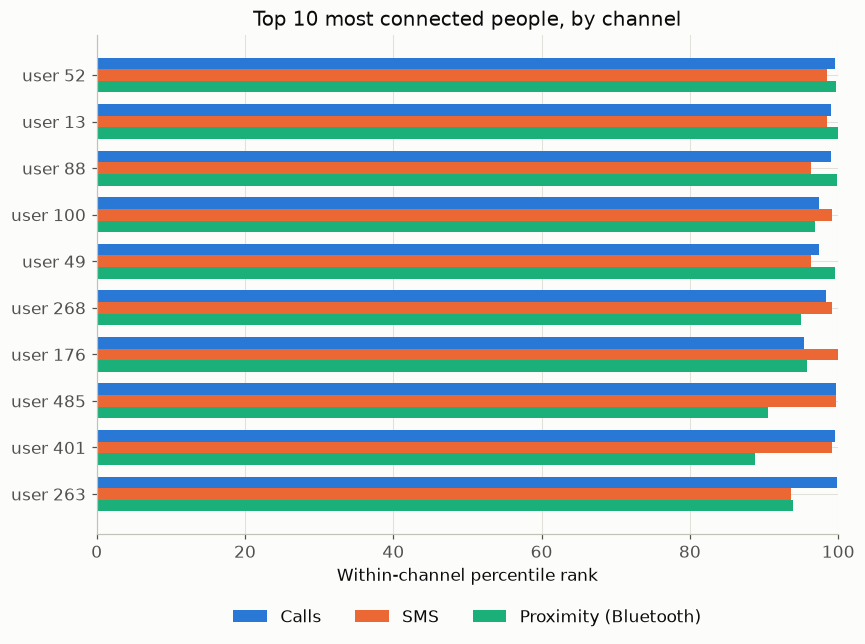

In [12]:
connectivity = pd.concat([
    pd.Series(degree_data["Calls"], name="calls_degree"),
    pd.Series(degree_data["SMS"], name="sms_degree"),
    pd.Series(degree_data["Proximity (Bluetooth)"], name="proximity_degree"),
], axis=1).fillna(0)

for col in ["calls_degree", "sms_degree", "proximity_degree"]:
    connectivity[col.replace("_degree", "_percentile")] = connectivity[col].rank(pct=True) * 100

connectivity["combined_score"] = connectivity[
    ["calls_percentile", "sms_percentile", "proximity_percentile"]
].mean(axis=1)
connectivity["gender"] = (
    connectivity.index.to_series().map(gender_map).map({0: "Male", 1: "Female"}).fillna("Unknown")
)

top10 = connectivity.sort_values("combined_score", ascending=False).head(10)
top10.index.name = "user"

display(
    top10[["calls_degree", "sms_degree", "proximity_degree", "combined_score", "gender"]].style.format(
        {"calls_degree": "{:.0f}", "sms_degree": "{:.0f}", "proximity_degree": "{:.0f}", "combined_score": "{:.1f}"}
    ).set_caption("Table 4. Top 10 most connected people (avg. within-channel percentile across calls, SMS, proximity)")
)

fig, ax = plt.subplots(figsize=(8, 6))
y = np.arange(len(top10))
bar_h = 0.25
channels = [
    ("calls_percentile", "Calls"),
    ("sms_percentile", "SMS"),
    ("proximity_percentile", "Proximity (Bluetooth)"),
]
for i, (col, label) in enumerate(channels):
    ax.barh(y + (i - 1) * bar_h, top10[col].values, height=bar_h, color=LAYER_COLOR[label], label=label)
ax.set_yticks(y)
ax.set_yticklabels([f"user {u}" for u in top10.index])
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel("Within-channel percentile rank")
ax.set_title("Top 10 most connected people, by channel")
ax.legend(
    frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3,
)
plt.tight_layout()
plt.show()

## 4. Tie strength — not every edge is equal

An edge that represents one missed call is a much weaker transmission channel than one built from a dozen completed calls. This section looks at call outcomes/durations and at how repeat contact is distributed across pairs.

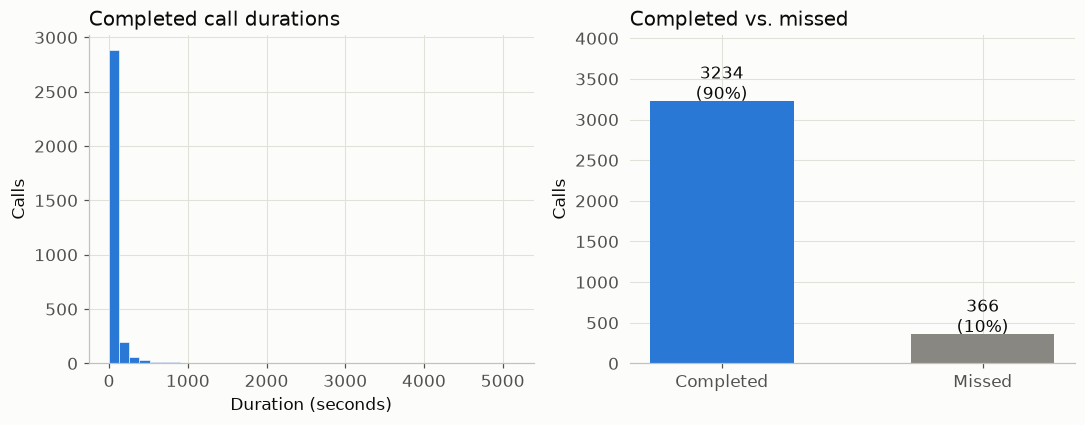

In [13]:
completed = calls[calls.duration >= 0]
missed = calls[calls.duration == -1]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(completed.duration, bins=40, color=LAYER_COLOR["Calls"], edgecolor=SURFACE, linewidth=0.4)
axes[0].set_xlabel("Duration (seconds)")
axes[0].set_ylabel("Calls")
axes[0].set_title("Completed call durations", loc="left")

status_counts = pd.Series({"Completed": len(completed), "Missed": len(missed)})
bars = axes[1].bar(
    status_counts.index, status_counts.values,
    color=[LAYER_COLOR["Calls"], INK_MUTED], width=0.55,
)
for bar, v in zip(bars, status_counts.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2, v + 20,
        f"{v}\n({v / status_counts.sum():.0%})", ha="center",
    )
axes[1].set_ylabel("Calls")
axes[1].set_title("Completed vs. missed", loc="left")
axes[1].set_ylim(0, status_counts.max() * 1.25)
axes[1].spines["left"].set_visible(False)
axes[1].tick_params(left=False)

plt.tight_layout()
plt.show()

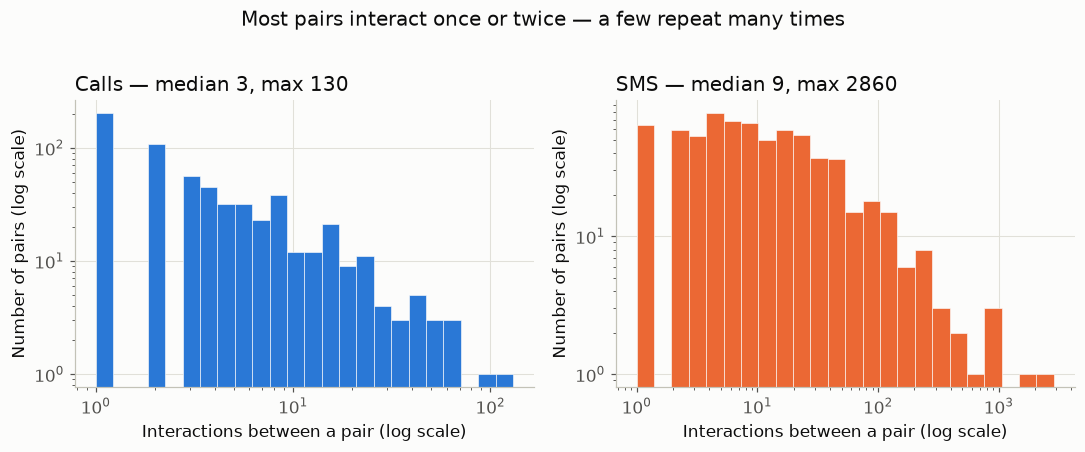

In [14]:
call_weights = calls.groupby("pair").size()
sms_weights = sms.groupby("pair").size()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, weights, label in zip(axes, [call_weights, sms_weights], ["Calls", "SMS"]):
    bins = np.logspace(0, np.log10(weights.max()), 25)
    ax.hist(weights, bins=bins, color=LAYER_COLOR[label], edgecolor=SURFACE, linewidth=0.4)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Interactions between a pair (log scale)")
    ax.set_ylabel("Number of pairs (log scale)")
    ax.set_title(f"{label} — median {int(weights.median())}, max {weights.max()}", loc="left")
fig.suptitle("Most pairs interact once or twice — a few repeat many times", y=1.02)
plt.tight_layout()
plt.show()

## 5. Proximity signal strength (Bluetooth RSSI)

For a rumor spreading through face-to-face contact rather than through phone/text, physical proximity is the relevant channel. RSSI is a proxy for distance: values closer to 0 mean the two phones were closer together.

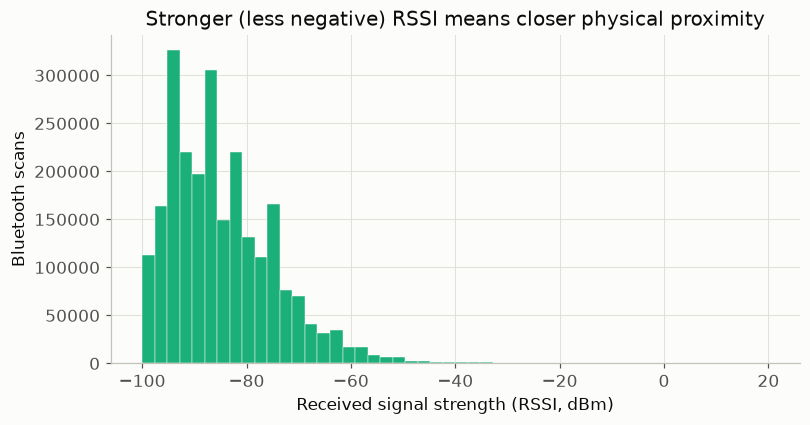

In [15]:
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.hist(bt_valid.rssi, bins=50, color=LAYER_COLOR["Proximity (Bluetooth)"], edgecolor=SURFACE, linewidth=0.3)
ax.set_xlabel("Received signal strength (RSSI, dBm)")
ax.set_ylabel("Bluetooth scans")
ax.set_title("Stronger (less negative) RSSI means closer physical proximity")
plt.tight_layout()
plt.show()

## 6. Cross-layer overlap — do the channels agree on who is "connected"?

A rumor could travel over any of these channels. If they mostly overlap, a single-layer model is a reasonable approximation; if they're largely disjoint, a multiplex (multi-layer) diffusion model is needed to avoid missing real transmission paths.

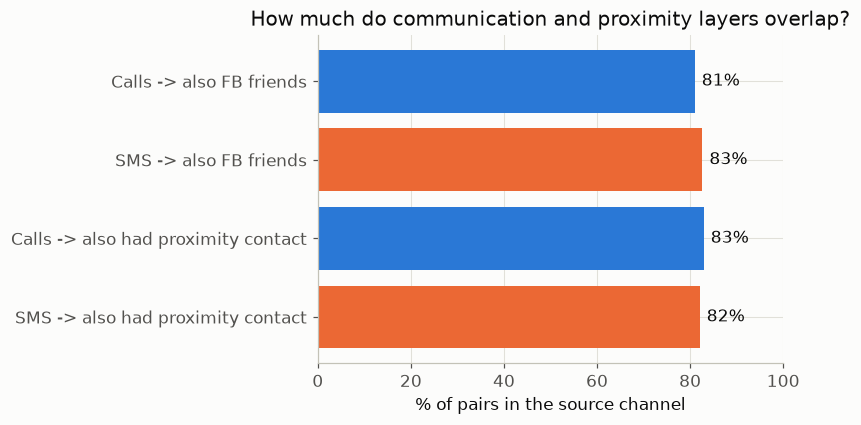

In [16]:
fb_pairs = set(pair_id(fb, "user_a", "user_b"))
call_pairs = set(calls["pair"].unique())
sms_pairs = set(sms["pair"].unique())
bt_pairs = set(bt_valid["pair"].unique())


def pct_overlap(source, reference):
    return len(source & reference) / len(source) * 100


rows = [
    ("Calls -> also FB friends", pct_overlap(call_pairs, fb_pairs), LAYER_COLOR["Calls"]),
    ("SMS -> also FB friends", pct_overlap(sms_pairs, fb_pairs), LAYER_COLOR["SMS"]),
    ("Calls -> also had proximity contact", pct_overlap(call_pairs, bt_pairs), LAYER_COLOR["Calls"]),
    ("SMS -> also had proximity contact", pct_overlap(sms_pairs, bt_pairs), LAYER_COLOR["SMS"]),
]
labels, values, colors = zip(*rows)

fig, ax = plt.subplots(figsize=(7.5, 4))
bars = ax.barh(labels, values, color=colors)
for bar, v in zip(bars, values):
    ax.text(v + 1.5, bar.get_y() + bar.get_height() / 2, f"{v:.0f}%", va="center")
ax.set_xlabel("% of pairs in the source channel")
ax.set_xlim(0, 100)
ax.invert_yaxis()
ax.set_title("How much do communication and proximity layers overlap?")
plt.tight_layout()
plt.show()

## 7. Summary — implications for rumor-spread modeling

- **Use a temporal, not static, network.** Contact volume follows a clear ~7-day cycle with dips (likely weekends), so a rumor's reach depends heavily on *when* it starts — a time-collapsed graph would overstate reachability.
- **The bottleneck is communication and friendship, not physical proximity.** Calls and SMS are sparse and heavy-tailed (most people contact ~2 others, a few reach 10+) and Facebook friendship is moderately heavy-tailed — both have real hub structure a mean-field model would miss. Bluetooth proximity is the opposite: almost everyone was recorded near 200+ others, so nearly everyone *could* be physically reached — the more decisive structure for *likely* spread paths lives in the sparser layers.
- **The face-to-face network's core has no single gatekeeper, even though a fifth of it is technically load-bearing.** 80 of the 393 people (20%) in the giant proximity component are cut vertices, but 45 of them only isolate one peripheral person, and the worst case isolates just 8 of 393 (2.0%). There's no single person whose removal would fracture the network into two large halves — a rumor's physical spread doesn't hinge on any one individual staying "in."
- **Weight edges by tie strength, not just presence.** Most pairs interact once or twice; a few interact often. Missed calls (~10% of call records) are zero-duration contact attempts and arguably shouldn't carry the same transmission probability as a completed call.
- **Consider a multiplex model.** The communication layers (calls, SMS) and the Facebook friendship graph overlap only partially, and proximity contact is far broader than either — so a rumor confined to one channel would miss a large share of plausible spreading paths present in the others.
- **Physical proximity is dense and roughly uniform, but RSSI still carries signal.** Contact intensity (RSSI) ranges from brief/faint to sustained/close, which could be used to weight proximity-based transmission probability even though raw proximity degree doesn't separate people much.
- **Gender coverage is incomplete (787 of ~800+ participants).** Any model that conditions on gender needs an explicit "unknown" category rather than dropping the uncovered participants, since they still appear throughout the interaction data.

## 8. Interactive network explorers (standalone HTML)

The three network drawings in Section 3 are static — good for seeing the overall shape, but hard to use for tracing one specific person's connections. Below, each one is rebuilt as a self-contained interactive HTML file (via [pyvis](https://pyvis.readthedocs.io/), a Python wrapper around the vis.js network library) that opens in any browser, no Jupyter required:

- **Hover** a node to see who it is (id, gender, degree, and channel-specific stats).
- **Click** a node to highlight its direct connections and dim everything else; click empty space to reset.
- **Drag** a node to reposition it — the rest of the layout stays put.
- **Scroll** to zoom, drag the background to pan.

Each file is written to `results/figures/` and also embedded below — that embed should render directly in Jupyter/VS Code's notebook viewer, but if it doesn't load in your setup, open the file straight from `results/figures/` in a browser instead.

In [ ]:
import json

from IPython.display import IFrame
from pyvis.network import Network
from pathlib import Path

RESULTS_DIR = Path("../results/figures")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


def gender_label(user):
    return {0: "Male", 1: "Female"}.get(gender_map.get(user), "Unknown")


def legend_html(items):
    dots = []
    for label, color, outline in items:
        style = (
            f"display:inline-block;width:10px;height:10px;border-radius:50%;border:2px solid {color};"
            if outline else
            f"display:inline-block;width:10px;height:10px;border-radius:50%;background:{color};"
        )
        dots.append(
            f'<span style="display:flex;align-items:center;gap:5px;"><span style="{style}"></span> {label}</span>'
        )
    return " &nbsp; ".join(dots)


PAGE_SCRIPT = """
<div id="viz-banner" style="
    position: fixed; top: 0; left: 0; right: 0; z-index: 1000;
    background: __SURFACE__; border-bottom: 1px solid __BASELINE__;
    font-family: system-ui, -apple-system, 'Segoe UI', sans-serif; color: __INK__;
    padding: 10px 16px; display: flex; align-items: center; gap: 20px; flex-wrap: wrap;">
  <strong style="font-size: 15px;">__TITLE__</strong>
  <span style="font-size: 12.5px; color: __INK_SECONDARY__;">
    Hover a node for details &middot; click a node to highlight its connections &middot;
    click empty space to reset &middot; drag a node to reposition &middot; scroll to zoom
  </span>
  <span style="margin-left: auto; display: flex; gap: 14px; font-size: 12.5px;">
    __LEGEND__
  </span>
</div>
<style>
  div.vis-tooltip {
    white-space: pre-line !important;
    font-family: system-ui, -apple-system, 'Segoe UI', sans-serif !important;
    font-size: 12.5px !important;
    max-width: 260px;
  }
</style>
<script type="text/javascript">
  (function () {
    function initInteractivity() {
      if (typeof network === "undefined" || typeof nodes === "undefined" || typeof edges === "undefined") {
        setTimeout(initInteractivity, 100);
        return;
      }
      var banner = document.getElementById("viz-banner");
      function syncBannerHeight() {
        if (banner) { document.body.style.paddingTop = banner.offsetHeight + "px"; }
      }
      syncBannerHeight();
      window.addEventListener("resize", syncBannerHeight);

      network.once("stabilizationIterationsDone", function () {
        network.setOptions({ physics: false });
      });

      var allNodeIds = nodes.getIds();
      var allEdgeIds = edges.getIds();
      var edgeBaseColor = "__EDGE_COLOR__";
      var highlightActive = false;

      function resetView() {
        nodes.update(allNodeIds.map(function (id) { return { id: id, opacity: 1 }; }));
        edges.update(allEdgeIds.map(function (id) {
          return { id: id, color: { color: edgeBaseColor, opacity: 0.35 } };
        }));
        highlightActive = false;
      }

      network.on("click", function (params) {
        if (params.nodes.length > 0) {
          var selected = params.nodes[0];
          var neighborSet = {};
          neighborSet[selected] = true;
          network.getConnectedNodes(selected).forEach(function (n) { neighborSet[n] = true; });
          var connectedEdgeIds = {};
          network.getConnectedEdges(selected).forEach(function (e) { connectedEdgeIds[e] = true; });

          nodes.update(allNodeIds.map(function (id) {
            return { id: id, opacity: neighborSet[id] ? 1 : 0.08 };
          }));
          edges.update(allEdgeIds.map(function (id) {
            return { id: id, color: { color: edgeBaseColor, opacity: connectedEdgeIds[id] ? 0.9 : 0.02 } };
          }));
          highlightActive = true;
        } else if (highlightActive) {
          resetView();
        }
      });
    }
    initInteractivity();
  })();
</script>
"""


def build_interactive_network(G, out_path, title, edge_color, legend_items,
                               node_title_fn, node_color_fn, node_size_fn,
                               node_border_fn=None):
    net = Network(
        height="100vh", width="100%", bgcolor=SURFACE, font_color=INK,
        cdn_resources="in_line", directed=False, notebook=False,
    )
    net.force_atlas_2based(gravity=-45, central_gravity=0.008, spring_length=90, spring_strength=0.06, damping=0.45)
    net.set_options(json.dumps({
        "nodes": {"borderWidth": 0, "font": {"size": 0}},
        "edges": {"smooth": False, "selectionWidth": 1},
        "interaction": {"hover": True, "tooltipDelay": 80, "navigationButtons": False, "keyboard": False},
        "physics": {"stabilization": {"iterations": 300, "fit": True}, "minVelocity": 1.2},
    }))

    for node in G.nodes():
        bg = node_color_fn(node)
        border = node_border_fn(node) if node_border_fn else None
        node_kwargs = {"color": {"background": bg, "border": border}, "borderWidth": 3} if border else {"color": bg}
        net.add_node(
            int(node), label="", title=node_title_fn(node),
            size=float(node_size_fn(node)), **node_kwargs,
        )
    for a, b, data in G.edges(data=True):
        net.add_edge(int(a), int(b), value=float(data.get("weight", 1)), color={"color": edge_color, "opacity": 0.35})

    out_file = RESULTS_DIR / out_path
    net.write_html(str(out_file), notebook=False)

    html = out_file.read_text()
    injected = (
        PAGE_SCRIPT
        .replace("__SURFACE__", SURFACE).replace("__BASELINE__", BASELINE)
        .replace("__INK__", INK).replace("__INK_SECONDARY__", INK_SECONDARY)
        .replace("__TITLE__", title).replace("__LEGEND__", legend_html(legend_items))
        .replace("__EDGE_COLOR__", edge_color)
    )
    html = html.replace("<body>", "<body>" + injected)
    out_file.write_text(html)
    print(f"wrote {out_file} ({out_file.stat().st_size / 1024:.0f} KB) — {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
    return out_file


GENDER_LEGEND = [("Male", GENDER_COLOR["Male"], False), ("Female", GENDER_COLOR["Female"], False), ("Unknown", INK_MUTED, False)]

NameError: name 'Path' is not defined

### Interactive: Facebook friendship network

In [18]:
fb_degree = dict(G_fb.degree())

fb_file = build_interactive_network(
    G_fb,
    out_path="fb_network_interactive.html",
    title="Facebook friendship network",
    edge_color=VIOLET,
    legend_items=GENDER_LEGEND,
    node_title_fn=lambda n: f"User {n}\nGender: {gender_label(n)}\nFacebook friends: {fb_degree[n]}",
    node_color_fn=lambda n: GENDER_COLOR.get(gender_label(n), INK_MUTED),
    node_size_fn=lambda n: min(10 + 1.5 * fb_degree[n], 45),
)

IFrame(src=str(fb_file), width="100%", height=650)

wrote ../results/figures/fb_network_interactive.html (1369 KB) — 800 nodes, 6429 edges


### Interactive: face-to-face contact network (Bluetooth proximity)

In [19]:
bt_strong_degree = dict(G_bt_strong.degree())
bt_strong_hours = {
    n: sum(d["weight"] for _, _, d in G_bt_strong.edges(n, data=True)) * SCAN_INTERVAL_MIN / 60
    for n in G_bt_strong.nodes()
}

proximity_file = build_interactive_network(
    G_bt_strong,
    out_path="face_to_face_network_interactive.html",
    title=f"Face-to-face contact network (≥{MIN_HOURS_TOGETHER}h cumulative proximity)",
    edge_color=AQUA,
    legend_items=GENDER_LEGEND,
    node_title_fn=lambda n: (
        f"User {n}\nGender: {gender_label(n)}\n"
        f"Strong contacts (≥{MIN_HOURS_TOGETHER}h): {bt_strong_degree[n]}\n"
        f"Total time together: {bt_strong_hours[n]:.0f}h"
    ),
    node_color_fn=lambda n: GENDER_COLOR.get(gender_label(n), INK_MUTED),
    node_size_fn=lambda n: min(10 + 1.5 * bt_strong_degree[n], 45),
)

IFrame(src=str(proximity_file), width="100%", height=650)

wrote ../results/figures/face_to_face_network_interactive.html (868 KB) — 460 nodes, 1004 edges


### Interactive: critical connectors (cut vertices)

In [20]:
cut_vertex_set = set(articulation_points)
impact_by_user = impact.set_index("user")["people_cut_off"]

critical_file = build_interactive_network(
    G_bt_strong,
    out_path="critical_connectors_interactive.html",
    title="Critical connectors in the face-to-face network",
    edge_color=AQUA,
    legend_items=GENDER_LEGEND + [("Cut vertex", RED, True)],
    node_title_fn=lambda n: (
        f"User {n}\nGender: {gender_label(n)}\nStrong contacts: {bt_strong_degree[n]}\n"
        + (
            f"Cut vertex: yes — removing them separates {int(impact_by_user.loc[n])} people"
            if n in cut_vertex_set else
            "Cut vertex: no"
        )
    ),
    node_color_fn=lambda n: GENDER_COLOR.get(gender_label(n), INK_MUTED),
    node_size_fn=lambda n: min(10 + 1.5 * bt_strong_degree[n], 45) + (10 if n in cut_vertex_set else 0),
    node_border_fn=lambda n: RED if n in cut_vertex_set else None,
)

IFrame(src=str(critical_file), width="100%", height=650)

wrote ../results/figures/critical_connectors_interactive.html (866 KB) — 460 nodes, 1004 edges
